H1 output folder: output/h1
Learning rates: [0.001, 0.01, 0.1, 0.5, 0.9]
Experiment seeds: [654571, 89250, 773955]

Loading MNIST data...
Preprossing data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0
Configuration: H1: Learning rate = 0.001
Seeds: [654571, 89250, 773955]

Run 1/3 using seed 654571
Epoch 1: Train loss=2.3001, Train accuracy=0.1521, Val loss=2.2979, Val accuracy=0

,Learning Rate,Train Accuracy Mean,Train Accuracy SD,Train Accuracy Mean ± SD,Validation Accuracy Mean,Validation Accuracy SD,Validation Accuracy Mean ± SD,Train Loss Mean,Train Loss SD,Train Loss Mean ± SD,Validation Loss Mean,Validation Loss SD,Validation Loss Mean ± SD
0,0.001,89.80%,0.04%,89.80% ± 0.04%,89.79%,0.06%,89.79% ± 0.06%,0.3670,0.0004,0.3670 ± 0.0004,0.3628,0.0002,0.3628 ± 0.0002
1,0.010,96.61%,0.15%,96.61% ± 0.15%,95.92%,0.08%,95.92% ± 0.08%,0.1247,0.0057,0.1247 ± 0.0057,0.1415,0.0056,0.1415 ± 0.0056
2,0.100,99.98%,0.00%,99.98% ± 0.00%,97.86%,0.09%,97.86% ± 0.09%,0.0057,0.0002,0.0057 ± 0.0002,0.0776,0.0027,0.0776 ± 0.0027
3,0.500,100.00%,0.00%,100.00% ± 0.00%,98.11%,0.09%,98.11% ± 0.09%,0.0004,0.0000,0.0004 ± 0.0000,0.0909,0.0025,0.0909 ± 0.0025
4,0.900,100.00%,0.00%,100.00% ± 0.00%,98.12%,0.16%,98.12% ± 0.16%,0.0002,0.0000,0.0002 ± 0.0000,0.1000,0.0101,0.1000 ± 0.0101


Saved: output/h1/h1_summary.csv
Saved: output/h1/h1_epoch_history.csv
Saved: output/h1/h1_learning_rate_0p001.png


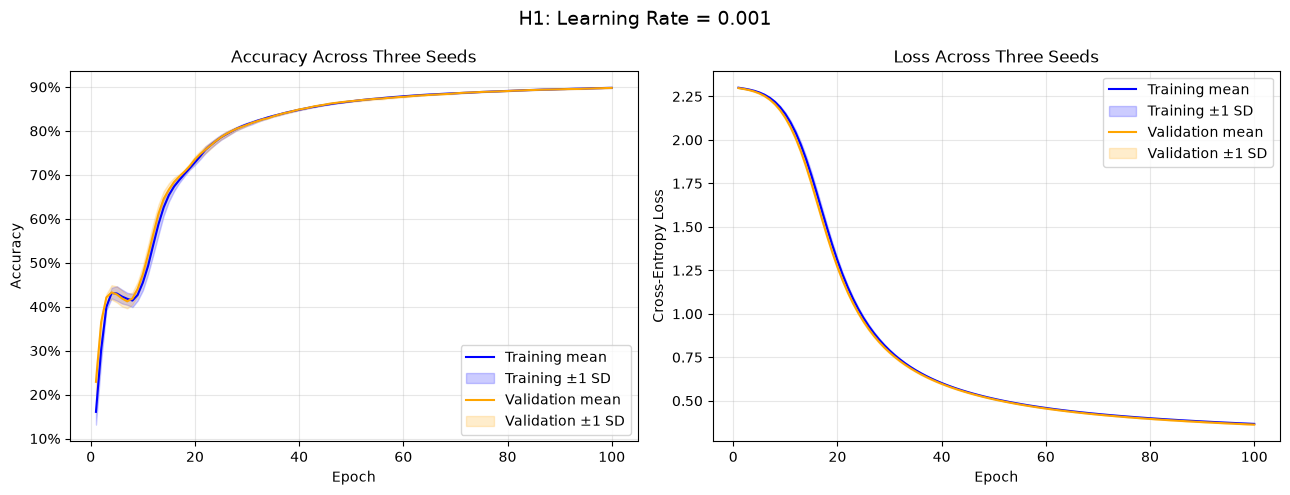

Saved: output/h1/h1_learning_rate_0p01.png


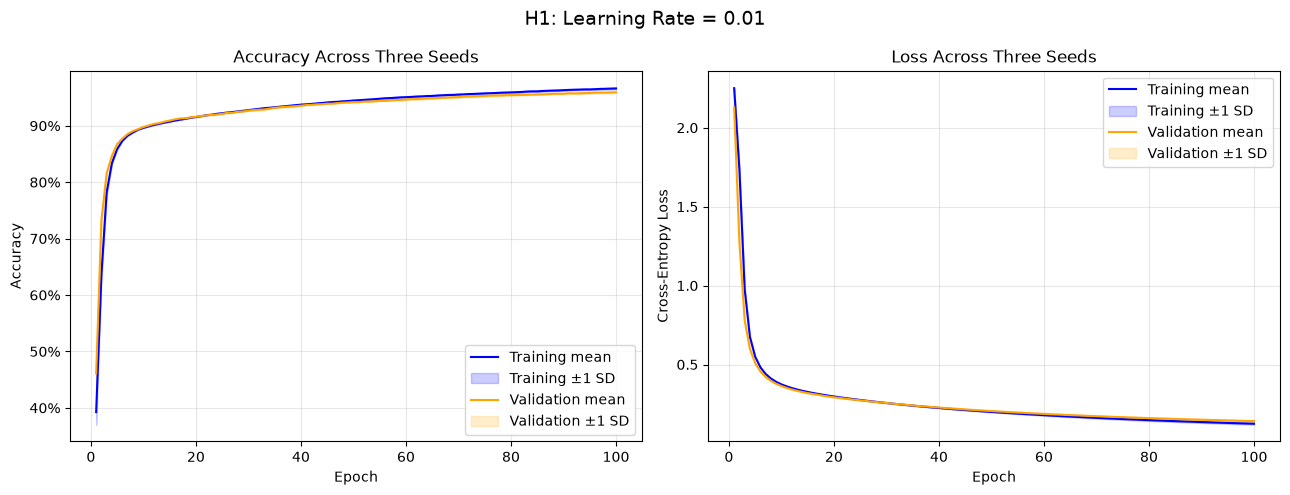

Saved: output/h1/h1_learning_rate_0p1.png


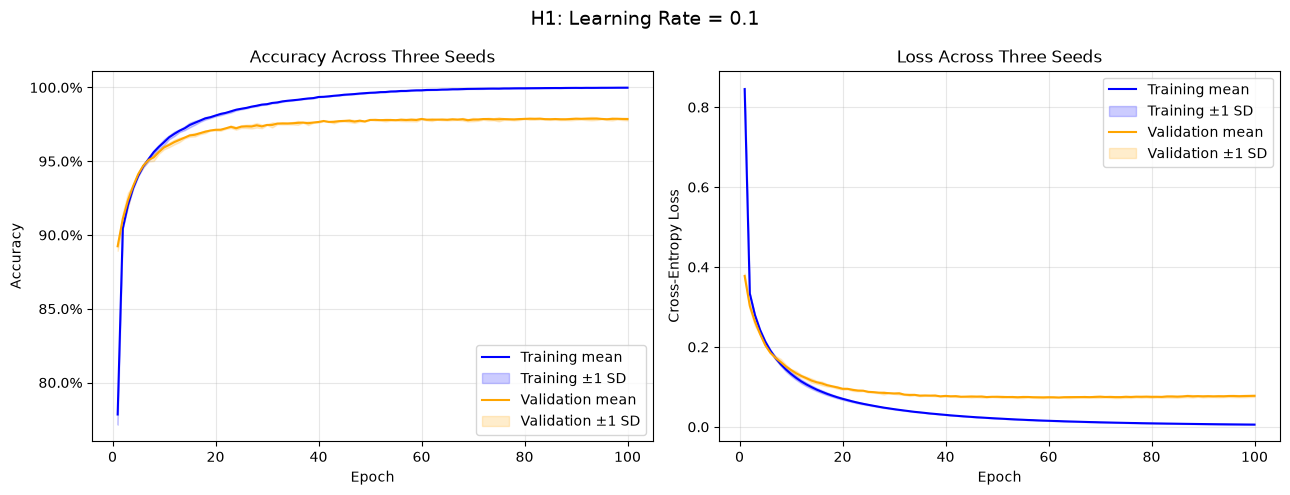

Saved: output/h1/h1_learning_rate_0p5.png


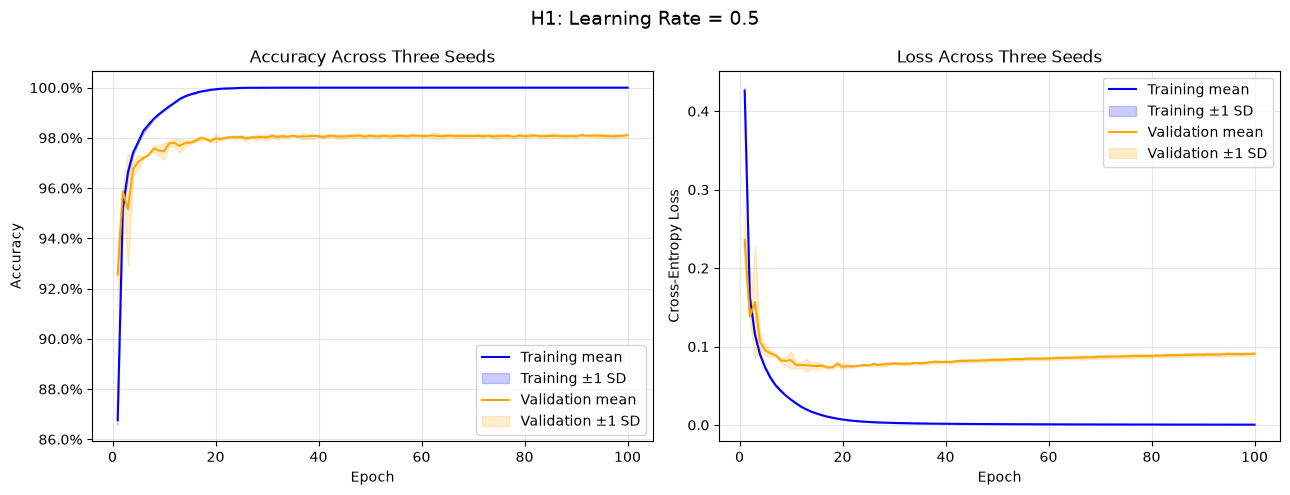

Saved: output/h1/h1_learning_rate_0p9.png


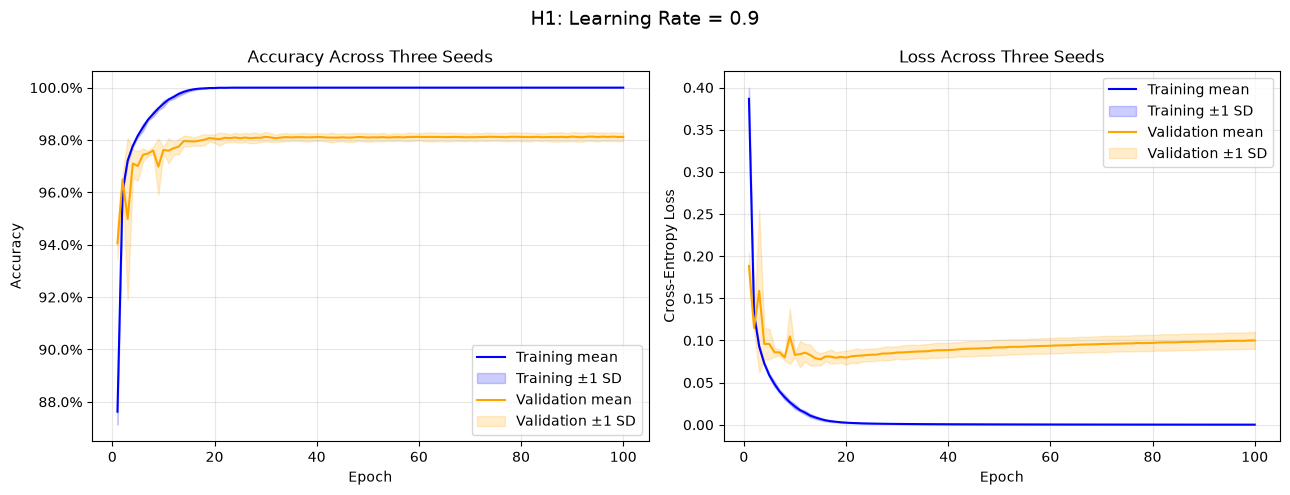


Files saved in output/h1:
h1_epoch_history.csv
h1_learning_rate_0p001.png
h1_learning_rate_0p01.png
h1_learning_rate_0p1.png
h1_learning_rate_0p5.png
h1_learning_rate_0p9.png
h1_summary.csv


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

from scratch import *
# ============================================================
# H1 settings and output folder
# ============================================================

H1_OUTPUT_DIR = "output/h1"

os.makedirs(
    H1_OUTPUT_DIR,
    exist_ok=True
)

EXPERIMENT_EPOCHS = 100
EXPERIMENT_SEEDS = generate_experiment_seeds(base_seed=SPLIT_SEED, number_of_seeds=3)

H1_LEARNING_RATES = [
    0.001,
    0.01,
    0.1,
    0.5,
    0.9
]

print("H1 output folder:", H1_OUTPUT_DIR)
print("Learning rates:", H1_LEARNING_RATES)
print("Experiment seeds:", EXPERIMENT_SEEDS)

print("\nLoading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprossing data...")

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)

# ============================================================
# Run H1 experiments
# ============================================================

h1_results = {}

for learning_rate in H1_LEARNING_RATES:
    configuration_name = (
        f"H1: Learning rate = {learning_rate}"
    )

    models, histories = run_three_seed_configuration(
        configuration_name=configuration_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        hidden_size=128,
        activation="relu",
        initialization="small",
        learning_rate=learning_rate,
        batch_size=128,
        epochs=EXPERIMENT_EPOCHS,
        seeds=EXPERIMENT_SEEDS,
        verbose=True
    )

    h1_results[learning_rate] = {
        "models": models,
        "histories": histories
    }


# ============================================================
# Create final-epoch H1 summary table
# ============================================================

h1_summary_rows = []

for learning_rate, result in h1_results.items():
    histories = result["histories"]

    final_train_accuracy = np.array([
        history["train_accuracy"][-1]
        for history in histories
    ])

    final_val_accuracy = np.array([
        history["val_accuracy"][-1]
        for history in histories
    ])

    final_train_loss = np.array([
        history["train_loss"][-1]
        for history in histories
    ])

    final_val_loss = np.array([
        history["val_loss"][-1]
        for history in histories
    ])

    mean_train_accuracy = np.mean(
        final_train_accuracy
    )

    std_train_accuracy = np.std(
        final_train_accuracy,
        ddof=1
    )

    mean_val_accuracy = np.mean(
        final_val_accuracy
    )

    std_val_accuracy = np.std(
        final_val_accuracy,
        ddof=1
    )

    mean_train_loss = np.mean(
        final_train_loss
    )

    std_train_loss = np.std(
        final_train_loss,
        ddof=1
    )

    mean_val_loss = np.mean(
        final_val_loss
    )

    std_val_loss = np.std(
        final_val_loss,
        ddof=1
    )

    h1_summary_rows.append({
        "Learning Rate": learning_rate,

        "Train Accuracy Mean": (
            f"{mean_train_accuracy * 100:.2f}%"
        ),
        "Train Accuracy SD": (
            f"{std_train_accuracy * 100:.2f}%"
        ),
        "Train Accuracy Mean ± SD": (
            f"{mean_train_accuracy * 100:.2f}% ± "
            f"{std_train_accuracy * 100:.2f}%"
        ),

        "Validation Accuracy Mean": (
            f"{mean_val_accuracy * 100:.2f}%"
        ),
        "Validation Accuracy SD": (
            f"{std_val_accuracy * 100:.2f}%"
        ),
        "Validation Accuracy Mean ± SD": (
            f"{mean_val_accuracy * 100:.2f}% ± "
            f"{std_val_accuracy * 100:.2f}%"
        ),

        "Train Loss Mean": (
            f"{mean_train_loss:.4f}"
        ),
        "Train Loss SD": (
            f"{std_train_loss:.4f}"
        ),
        "Train Loss Mean ± SD": (
            f"{mean_train_loss:.4f} ± "
            f"{std_train_loss:.4f}"
        ),

        "Validation Loss Mean": (
            f"{mean_val_loss:.4f}"
        ),
        "Validation Loss SD": (
            f"{std_val_loss:.4f}"
        ),
        "Validation Loss Mean ± SD": (
            f"{mean_val_loss:.4f} ± "
            f"{std_val_loss:.4f}"
        )
    })


h1_summary_table = pd.DataFrame(
    h1_summary_rows
)

print("\nH1 final-epoch results across three seeds")
display(h1_summary_table)


# ============================================================
# Save H1 summary table
# ============================================================

h1_summary_path = os.path.join(
    H1_OUTPUT_DIR,
    "h1_summary.csv"
)

h1_summary_table.to_csv(
    h1_summary_path,
    index=False
)

print("Saved:", h1_summary_path)


# ============================================================
# Create and save raw epoch-history table
# ============================================================

h1_history_rows = []

for learning_rate, result in h1_results.items():
    histories = result["histories"]

    for seed, history in zip(
        EXPERIMENT_SEEDS,
        histories
    ):
        number_of_epochs = len(
            history["train_loss"]
        )

        for epoch_index in range(number_of_epochs):
            h1_history_rows.append({
                "learning_rate": learning_rate,
                "seed": seed,
                "epoch": epoch_index + 1,
                "train_loss": (
                    history["train_loss"][epoch_index]
                ),
                "train_accuracy": (
                    history["train_accuracy"][epoch_index]
                ),
                "validation_loss": (
                    history["val_loss"][epoch_index]
                ),
                "validation_accuracy": (
                    history["val_accuracy"][epoch_index]
                )
            })


h1_history_table = pd.DataFrame(
    h1_history_rows
)

h1_history_path = os.path.join(
    H1_OUTPUT_DIR,
    "h1_epoch_history.csv"
)

h1_history_table.to_csv(
    h1_history_path,
    index=False
)

print("Saved:", h1_history_path)


# ============================================================
# Plotting function with file saving
# ============================================================

def plot_and_save_three_seed_results(
    histories,
    configuration_name,
    save_path
):
    train_accuracy = np.array([
        history["train_accuracy"]
        for history in histories
    ])

    val_accuracy = np.array([
        history["val_accuracy"]
        for history in histories
    ])

    train_loss = np.array([
        history["train_loss"]
        for history in histories
    ])

    val_loss = np.array([
        history["val_loss"]
        for history in histories
    ])

    epochs = np.arange(
        1,
        train_accuracy.shape[1] + 1
    )

    # Means across seeds at every epoch
    mean_train_accuracy = np.mean(
        train_accuracy,
        axis=0
    )

    mean_val_accuracy = np.mean(
        val_accuracy,
        axis=0
    )

    mean_train_loss = np.mean(
        train_loss,
        axis=0
    )

    mean_val_loss = np.mean(
        val_loss,
        axis=0
    )

    # Sample standard deviations across seeds
    std_train_accuracy = np.std(
        train_accuracy,
        axis=0,
        ddof=1
    )

    std_val_accuracy = np.std(
        val_accuracy,
        axis=0,
        ddof=1
    )

    std_train_loss = np.std(
        train_loss,
        axis=0,
        ddof=1
    )

    std_val_loss = np.std(
        val_loss,
        axis=0,
        ddof=1
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5)
    )

    # --------------------------------------------------------
    # Accuracy subplot
    # --------------------------------------------------------

    axes[0].plot(
        epochs,
        mean_train_accuracy,
        color="blue",
        label="Training mean"
    )

    axes[0].fill_between(
        epochs,
        np.clip(
            mean_train_accuracy
            - std_train_accuracy,
            0.0,
            1.0
        ),
        np.clip(
            mean_train_accuracy
            + std_train_accuracy,
            0.0,
            1.0
        ),
        color="blue",
        alpha=0.2,
        label="Training ±1 SD"
    )

    axes[0].plot(
        epochs,
        mean_val_accuracy,
        color="orange",
        label="Validation mean"
    )

    axes[0].fill_between(
        epochs,
        np.clip(
            mean_val_accuracy
            - std_val_accuracy,
            0.0,
            1.0
        ),
        np.clip(
            mean_val_accuracy
            + std_val_accuracy,
            0.0,
            1.0
        ),
        color="orange",
        alpha=0.2,
        label="Validation ±1 SD"
    )

    axes[0].set_title(
        "Accuracy Across Three Seeds"
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")

    axes[0].yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --------------------------------------------------------
    # Loss subplot
    # --------------------------------------------------------

    axes[1].plot(
        epochs,
        mean_train_loss,
        color="blue",
        label="Training mean"
    )

    axes[1].fill_between(
        epochs,
        np.maximum(
            mean_train_loss - std_train_loss,
            0.0
        ),
        mean_train_loss + std_train_loss,
        color="blue",
        alpha=0.2,
        label="Training ±1 SD"
    )

    axes[1].plot(
        epochs,
        mean_val_loss,
        color="orange",
        label="Validation mean"
    )

    axes[1].fill_between(
        epochs,
        np.maximum(
            mean_val_loss - std_val_loss,
            0.0
        ),
        mean_val_loss + std_val_loss,
        color="orange",
        alpha=0.2,
        label="Validation ±1 SD"
    )

    axes[1].set_title(
        "Loss Across Three Seeds"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Cross-Entropy Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(
        configuration_name,
        fontsize=14
    )

    plt.tight_layout()

    # Save before displaying
    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()
    plt.close(fig)


# ============================================================
# Generate and save every H1 figure
# ============================================================

for learning_rate, result in h1_results.items():
    learning_rate_text = str(
        learning_rate
    ).replace(".", "p")

    plot_path = os.path.join(
        H1_OUTPUT_DIR,
        f"h1_learning_rate_{learning_rate_text}.png"
    )

    plot_and_save_three_seed_results(
        histories=result["histories"],
        configuration_name=(
            f"H1: Learning Rate = {learning_rate}"
        ),
        save_path=plot_path
    )


# ============================================================
# Verify all saved H1 files
# ============================================================

print("\nFiles saved in output/h1:")

for filename in sorted(
    os.listdir(H1_OUTPUT_DIR)
):
    print(filename)